## Project layout

Resolve the repo subdirectories so the rest of the notebook is
cwd-independent and figures land in the shared `figures/` folder.


In [1]:
# Project layout: notebooks live in <root>/notebooks/, source in
# <root>/src/, persistent datasets in <root>/data/, saved figures in
# <root>/figures/. We resolve these once so the rest of the notebook is
# cwd-independent.
from pathlib import Path
import sys

REPO_ROOT   = Path.cwd().resolve().parent
SRC_DIR     = REPO_ROOT / 'src'
DATA_DIR    = REPO_ROOT / 'data'
FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pockmark_model import MF6_EXE


# Offset overpressure scenario — with continuous seal

Identical to the offset-overpressure notebook but with an optional
**continuous low-permeability seal interbed** within the sand column.
The seal spans the full domain width at a given depth, trapping overpressure
below it and throttling vertical drainage.

The mud body remains centred at `Lx / 2`; the overpressure source is offset
laterally so that it lies well clear of the mud body edge.

Everything is self-contained — only `pockmark_model.py` is required.

## Imports and constants

In [2]:
import contextlib
import io
import warnings
from pathlib import Path
from tempfile import TemporaryDirectory

import flopy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from pockmark_model import (
    PERM_FACTOR, G, RHO_SEAWATER,
    SUBLAYER_THICK, N_SUBLAYERS, MUD_MAX_DEPTH,
    overpressure_to_head, critical_gradient,
    _build_mud_base, _harmonic_k_for_sublayer,
    _zero_record, _record_from_gradient,
)

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## Parameters

Edit the `SCENARIO` dict to change the run.

**Offset geometry**: `ovp_offset` shifts the overpressure source centre
away from `Lx / 2` (positive = rightward). The mud body stays at `Lx / 2`.

**Seal**: set `seal_thickness > 0` to activate the continuous low-k interbed.
`seal_depth` is measured from the seafloor to the seal centre; `seal_k` is
its hydraulic conductivity. Leave `seal_k = None` to default to `k_mud`.

In [3]:
SCENARIO = dict(
    # ── Baseline physical parameters (from main sweep admissible centre) ──
    overpressure_mpa = 1.55,
    k_mud            = 1e-19 * PERM_FACTOR,
    k_sand           = 1e-11 * PERM_FACTOR,
    ovp_thickness    = 30.0,
    bulkrho_mud      = 1650.0,
    bulkrho_sand     = 2150.0,
    ss               = 1e-4,
    sy               = 0.15,
    # ── Domain geometry ───────────────────────────────────────────────────
    Lx               = 210_000.0,   # wider domain to accommodate offset source
    mud_width        = 35_000.0,    # mud body centred at Lx/2
    depth_to_source  = 300.0,
    ncol             = 5000,
    # ── Offset overpressure ───────────────────────────────────────────────
    ovp_offset         = 35_500.0,   # shift source centre from domain centre [m]
    ovp_lateral_extent = 35_000.0,   # width of pressurised patch [m]
    # ── Continuous seal interbed ──────────────────────────────────────────
    seal_depth     = 150.0,    # depth from seafloor to seal centre [m]
    seal_thickness =  50.0,    # seal thickness [m]; set to 0.0 to disable
    seal_k         = None,     # seal conductivity [m/yr]; None → defaults to k_mud
)


## Patched simulation function

`run_simulation_offset_seal` extends `pockmark_model.run_simulation` with
both the `ovp_offset` lateral shift **and** the full seal-interbed logic
from the original model (identical layer-splitting and k assignment).

Set `seal_thickness = 0` to run without the seal.

In [4]:
def run_simulation_offset_seal(
    overpressure_mpa: float,
    k_mud: float,
    k_sand: float,
    ovp_thickness: float,
    bulkrho_mud: float,
    bulkrho_sand: float,
    ss: float,
    sy: float,
    Lx: float,
    mud_width: float,
    depth_to_source: float,
    ncol: int,
    ovp_offset: float,
    ovp_lateral_extent: float,
    seal_depth: float = 150.0,
    seal_thickness: float = 0.0,
    seal_k: float | None = None,
    # time discretisation
    perlen_sub: float = 1.0,   nstp_sub: int = 10,
    perlen_init: float = 4.0,  nstp_init: int = 4,
    perlen_early: float = 990.0,  nstp_early: int = 198,
    perlen_late: float = 29000.0, nstp_late: int = 290,
    modelname: str = 'ovp_seal',
):
    """
    Offset overpressure + optional continuous seal interbed.

    Mud body centred at Lx/2; overpressure source centred at Lx/2 + ovp_offset.
    Seal spans the full domain width when seal_thickness > 0.
    """
    if seal_k is None:
        seal_k = k_mud

    overpressure_head = overpressure_to_head(overpressure_mpa)
    crit_grad_mud  = critical_gradient(bulkrho_mud)
    crit_grad_sand = critical_gradient(bulkrho_sand)

    nrow   = 1
    delrow = Lx / 3.0
    delcol = Lx / ncol

    src_top_z  = -depth_to_source
    sand_top_z = -MUD_MAX_DEPTH
    use_seal   = seal_thickness > 0

    if use_seal:
        seal_top = -(seal_depth - seal_thickness / 2.0)
        seal_bot = -(seal_depth + seal_thickness / 2.0)
        if not (sand_top_z > seal_top > seal_bot > src_top_z):
            raise ValueError(
                f'Seal at depth {seal_depth} m thickness {seal_thickness} m '
                f'does not fit between {sand_top_z} m and {src_top_z} m.'
            )
        nlay = N_SUBLAYERS + 4   # sublayers + sand-above + seal + sand-below + ovp
    else:
        nlay = N_SUBLAYERS + 2   # sublayers + bulk-sand + ovp

    botm = np.zeros((nlay, nrow, ncol))
    for sl in range(N_SUBLAYERS):
        botm[sl, 0, :] = -(sl + 1) * SUBLAYER_THICK
    if use_seal:
        botm[N_SUBLAYERS,     0, :] = seal_top
        botm[N_SUBLAYERS + 1, 0, :] = seal_bot
        botm[N_SUBLAYERS + 2, 0, :] = src_top_z
        botm[N_SUBLAYERS + 3, 0, :] = src_top_z - ovp_thickness
    else:
        botm[N_SUBLAYERS,     0, :] = src_top_z
        botm[N_SUBLAYERS + 1, 0, :] = src_top_z - ovp_thickness

    mud_base = _build_mud_base(ncol, delcol, Lx, mud_width)
    k_layers = []
    for sl in range(N_SUBLAYERS):
        cell_top = -sl * SUBLAYER_THICK
        cell_bot = -(sl + 1) * SUBLAYER_THICK
        k_layers.append(_harmonic_k_for_sublayer(cell_top, cell_bot, mud_base, k_mud, k_sand))
    if use_seal:
        k_layers.append(np.full(ncol, k_sand))   # bulk sand above seal
        k_layers.append(np.full(ncol, seal_k))   # seal interbed
        k_layers.append(np.full(ncol, k_sand))   # bulk sand below seal
    else:
        k_layers.append(np.full(ncol, k_sand))   # bulk sand
    k_layers.append(np.full(ncol, k_sand))       # ovp source layer

    temp_dir  = TemporaryDirectory(delete=False)
    workspace = Path(temp_dir.name)

    sim = flopy.mf6.MFSimulation(
        sim_name=modelname, exe_name=str(MF6_EXE), sim_ws=workspace,
    )
    flopy.mf6.ModflowTdis(
        sim, pname='tdis', time_units='YEARS', nper=4,
        perioddata=[
            (perlen_sub,   nstp_sub,   1.0),
            (perlen_init,  nstp_init,  1.0),
            (perlen_early, nstp_early, 1.0),
            (perlen_late,  nstp_late,  1.0),
        ],
    )
    flopy.mf6.ModflowIms(
        sim, pname='ims',
        complexity='MODERATE',
        linear_acceleration='BICGSTAB',
        outer_maximum=500,
        inner_maximum=100,
        outer_dvclose=1e-6,
        inner_dvclose=1e-7,
        rcloserecord=1e-4,
    )
    gwf = flopy.mf6.ModflowGwf(
        sim, modelname=modelname, model_nam_file=f'{modelname}.nam',
        save_flows=False, newtonoptions='NEWTON UNDER_RELAXATION',
    )
    flopy.mf6.ModflowGwfdis(
        gwf, nlay=nlay, nrow=nrow, ncol=ncol,
        delr=delrow, delc=delcol, top=0.0, botm=botm,
    )

    # Offset overpressure initial condition
    strt = np.zeros((nlay, nrow, ncol))
    x_centres = (np.arange(ncol) + 0.5) * delcol
    ovp_centre = Lx / 2.0 + ovp_offset
    ovp_mask   = np.abs(x_centres - ovp_centre) <= ovp_lateral_extent / 2.0
    strt[nlay - 1, 0, ovp_mask] = overpressure_head

    flopy.mf6.ModflowGwfic(gwf, pname='ic', strt=strt)
    flopy.mf6.ModflowGwfnpf(gwf, icelltype=1, k=k_layers)
    flopy.mf6.ModflowGwfsto(
        gwf, ss=ss, sy=sy, transient={i: True for i in range(4)},
    )

    chd_rec = [((0, 0, col), 0.0) for col in range(ncol)]
    flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_rec)

    headfile = f'{modelname}.hds'
    flopy.mf6.ModflowGwfoc(
        gwf, saverecord=[('HEAD', 'ALL')],
        head_filerecord=[headfile], printrecord=[('HEAD', 'LAST')],
    )

    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        sim.write_simulation()
        success, buff = sim.run_simulation(silent=False, report=True)
    if not success:
        # Print last 50 lines of MODFLOW output to help diagnose
        mf_out = '\n'.join(str(b) for b in buff[-50:]) if buff else buf.getvalue()
        raise RuntimeError(
            f'MODFLOW 6 did not terminate normally.\n\nLast output:\n{mf_out}'
        )

    head_file = gwf.output.head()
    times     = head_file.get_times()
    kstpkpers = head_file.get_kstpkper()
    in_mud_zone = k_layers[0] == k_mud

    records      = [_zero_record()]
    grad_spatial = [np.zeros(ncol)]
    for t, ksp in zip(times, kstpkpers):
        h    = head_file.get_data(kstpkper=ksp)
        grad = (h[1, 0, :] - h[0, 0, :]) / SUBLAYER_THICK
        records.append(_record_from_gradient(
            t, ksp, grad, in_mud_zone, crit_grad_mud, crit_grad_sand
        ))
        grad_spatial.append(grad)

    results = pd.DataFrame(records)
    head_file.file.close()
    try:
        temp_dir.cleanup()
    except Exception:
        pass

    return (
        results, crit_grad_mud, crit_grad_sand,
        np.array(grad_spatial), x_centres, in_mud_zone,
    )

print('run_simulation_offset_seal defined')


run_simulation_offset_seal defined


## Run the simulation

In [5]:
import time
t0 = time.time()
results, crit_mud, crit_sand, grad_spatial, x_coords, in_mud_zone = \
    run_simulation_offset_seal(**SCENARIO)
print(f'Simulation complete in {time.time()-t0:.1f} s')
print(f'Critical gradient — mud: {crit_mud:.4f}  sand: {crit_sand:.4f}')

use_seal = SCENARIO.get('seal_thickness', 0) > 0
seal_k_val = SCENARIO.get('seal_k') or SCENARIO['k_mud']
if use_seal:
    print(f"Seal: depth {SCENARIO['seal_depth']} m, "
          f"thickness {SCENARIO['seal_thickness']} m, "
          f"k = {seal_k_val:.3e} m/yr")
else:
    print('No seal (seal_thickness = 0)')
results.tail()


Simulation complete in 9.9 s
Critical gradient — mud: 0.6113  sand: 1.0996
Seal: depth 150.0 m, thickness 50.0 m, k = 3.156e-05 m/yr


,time,kstpkper,max_gradient_mud,exceeds_critical_mud,col_index_mud,max_gradient_sand,exceeds_critical_sand,col_index_sand,overall_max_gradient,overall_max_col
498,29595.0,"(285, 3)",0.008563,False,2904,0.008650,False,2905,0.008650,2905
499,29695.0,"(286, 3)",0.008570,False,2904,0.008655,False,2905,0.008655,2905
500,29795.0,"(287, 3)",0.008577,False,2904,0.008659,False,2905,0.008659,2905
501,29895.0,"(288, 3)",0.008584,False,2904,0.008664,False,2905,0.008664,2905
502,29995.0,"(289, 3)",0.008591,False,2904,0.008668,False,2905,0.008668,2905


## Geometry overview

Shows the spatial layout: mud zone, overpressure source patch, and domain boundaries.

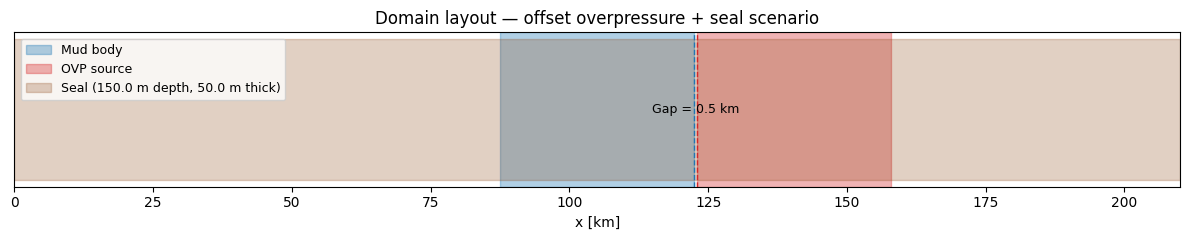

Mud body:   87.5 – 122.5 km
OVP source: 123.0 – 158.0 km
Separation: 0.5 km
Seal:       depth 150.0 m, thickness 50.0 m, full domain width


In [6]:
Lx        = SCENARIO['Lx']
mud_half  = SCENARIO['mud_width'] / 2.0
mud_left  = Lx / 2 - mud_half
mud_right = Lx / 2 + mud_half
ovp_cen   = Lx / 2 + SCENARIO['ovp_offset']
ovp_half  = SCENARIO['ovp_lateral_extent'] / 2.0
ovp_left  = ovp_cen - ovp_half
ovp_right = ovp_cen + ovp_half
separation = ovp_left - mud_right

use_seal      = SCENARIO.get('seal_thickness', 0) > 0
seal_depth    = SCENARIO.get('seal_depth', 150)
seal_thick    = SCENARIO.get('seal_thickness', 0)

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axvspan(mud_left/1e3,  mud_right/1e3, color='#1f77b4', alpha=0.35, label='Mud body')
ax.axvspan(ovp_left/1e3,  ovp_right/1e3, color='#d62728', alpha=0.35, label='OVP source')
ax.axvline(mud_right/1e3, color='#1f77b4', lw=1, ls='--')
ax.axvline(ovp_left/1e3,  color='#d62728', lw=1, ls='--')
if use_seal:
    ax.axhspan(0.15, 0.30, color='#8B4513', alpha=0.25, label=f'Seal ({seal_depth} m depth, {seal_thick} m thick)')
ax.annotate(
    f'Gap = {separation/1e3:.1f} km',
    xy=((mud_right + ovp_left) / 2e3, 0.5), xycoords=('data', 'axes fraction'),
    ha='center', va='center', fontsize=9,
)
ax.set_xlim(0, Lx/1e3)
ax.set_xlabel('x [km]')
ax.set_yticks([])
ax.legend(loc='upper left', fontsize=9)
ax.set_title('Domain layout — offset overpressure + seal scenario')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_offset_geometry.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Mud body:   {mud_left/1e3:.1f} – {mud_right/1e3:.1f} km')
print(f'OVP source: {ovp_left/1e3:.1f} – {ovp_right/1e3:.1f} km')
print(f'Separation: {separation/1e3:.1f} km')
if use_seal:
    print(f'Seal:       depth {seal_depth} m, thickness {seal_thick} m, full domain width')


## Gradient time series — mud vs sand

Maximum upward exit gradient in the mud zone and sand zone over time,
compared against the Terzaghi critical gradients.

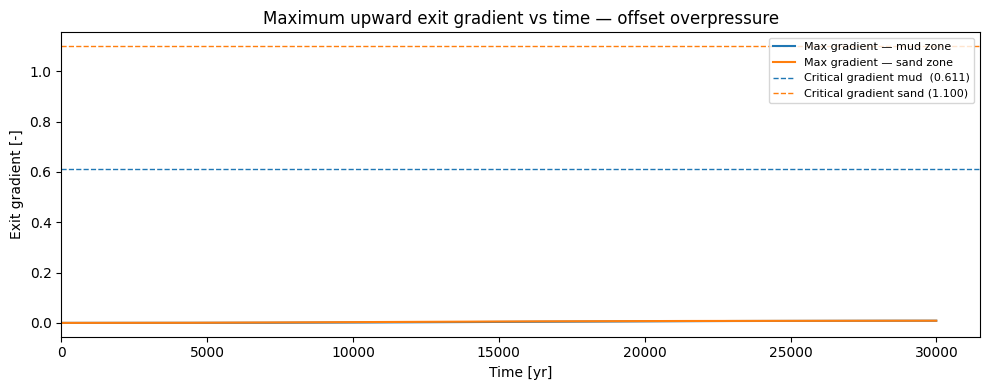

In [7]:
MUD_COLOR  = '#1f77b4'
SAND_COLOR = '#ff7f0e'

fig, ax = plt.subplots(figsize=(10, 4))
t = results['time']
ax.plot(t, results['max_gradient_mud'],  color=MUD_COLOR,  lw=1.5, label='Max gradient — mud zone')
ax.plot(t, results['max_gradient_sand'], color=SAND_COLOR, lw=1.5, label='Max gradient — sand zone')
ax.axhline(crit_mud,  color=MUD_COLOR,  ls='--', lw=1, label=f'Critical gradient mud  ({crit_mud:.3f})')
ax.axhline(crit_sand, color=SAND_COLOR, ls='--', lw=1, label=f'Critical gradient sand ({crit_sand:.3f})')
ax.set_xlabel('Time [yr]')
ax.set_ylabel('Exit gradient [-]')
ax.set_title('Maximum upward exit gradient vs time — offset overpressure')
ax.legend(fontsize=8)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_offset_gradient_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()

## Spatial gradient snapshots

Spatial profile of the upward exit gradient across the domain at selected times.
The mud zone is shaded blue, the overpressure source extent is shaded red.
Critical gradients are shown as dashed horizontal lines.

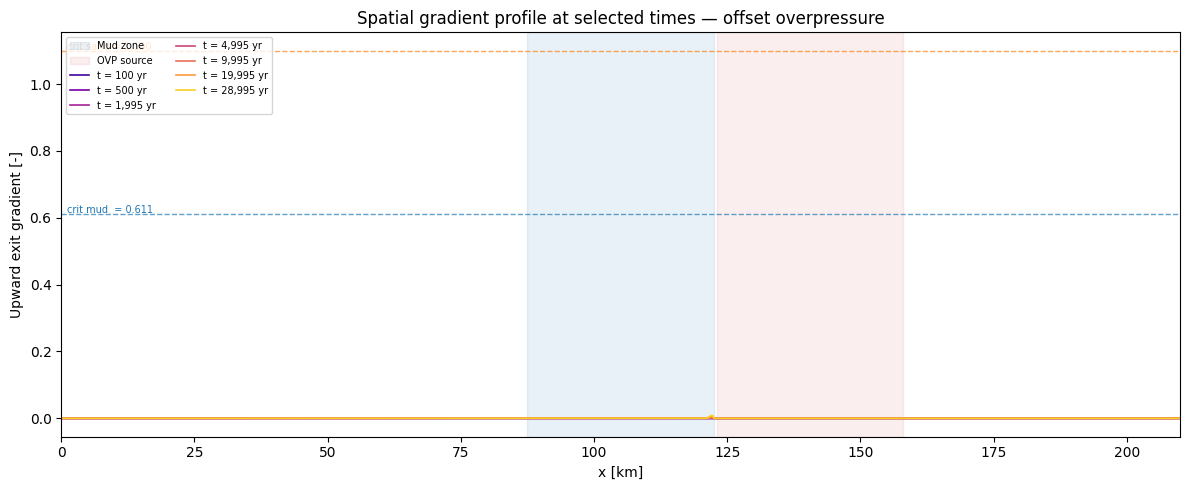

In [8]:
# Pick ~6 representative snapshots spread across the simulation
all_times = results['time'].values
snap_targets = np.array([100, 500, 2000, 5000, 10000, 20000, 29000])
snap_idxs = [np.argmin(np.abs(all_times - t)) for t in snap_targets]
snap_idxs = sorted(set(snap_idxs))

cmap = plt.cm.plasma
colors = cmap(np.linspace(0.1, 0.9, len(snap_idxs)))

fig, ax = plt.subplots(figsize=(12, 5))

# Shade mud zone and OVP source zone
ax.axvspan(mud_left/1e3,  mud_right/1e3, color=MUD_COLOR,  alpha=0.10, zorder=0, label='Mud zone')
ax.axvspan(ovp_left/1e3,  ovp_right/1e3, color='#d62728',  alpha=0.08, zorder=0, label='OVP source')

for idx, color in zip(snap_idxs, colors):
    ax.plot(x_coords / 1e3, grad_spatial[idx],
            color=color, lw=1.2, label=f't = {all_times[idx]:,.0f} yr')

ax.axhline(crit_mud,  color=MUD_COLOR,  ls='--', lw=1, alpha=0.7)
ax.axhline(crit_sand, color=SAND_COLOR, ls='--', lw=1, alpha=0.7)
ax.text(1, crit_mud  + 0.002, f'crit mud  = {crit_mud:.3f}',  color=MUD_COLOR,  fontsize=7)
ax.text(1, crit_sand + 0.002, f'crit sand = {crit_sand:.3f}', color=SAND_COLOR, fontsize=7)

ax.set_xlabel('x [km]')
ax.set_ylabel('Upward exit gradient [-]')
ax.set_title('Spatial gradient profile at selected times — offset overpressure')
ax.set_xlim(0, Lx / 1e3)
ax.legend(fontsize=7, ncol=2, loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_offset_spatial_snapshots.png', dpi=200, bbox_inches='tight')
plt.show()

## Gradient heatmap

Full space–time picture: colour = upward exit gradient.
Vertical dashed lines mark mud-body edges and OVP source edges.

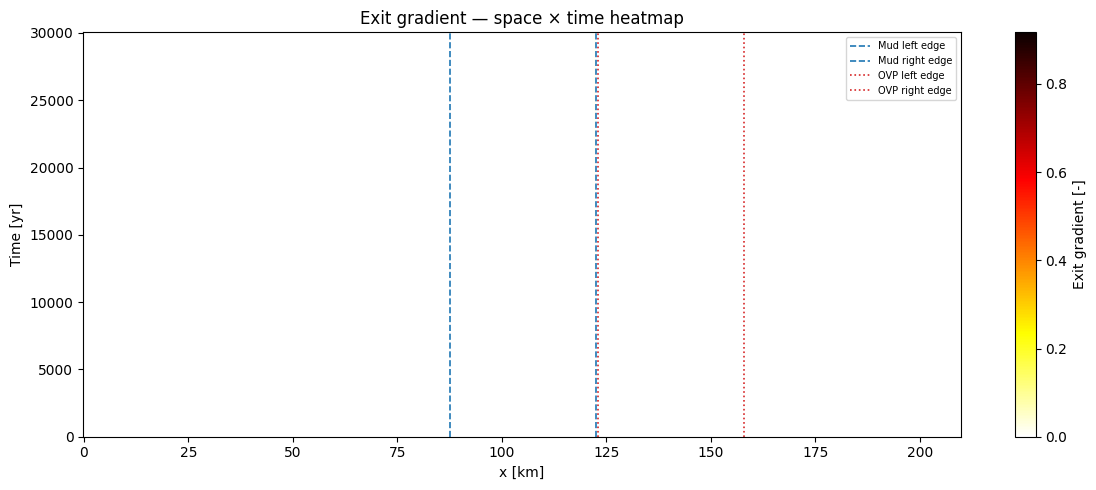

In [9]:
# Downsample columns for plotting speed
step = max(1, len(x_coords) // 500)
x_ds = x_coords[::step] / 1e3
g_ds = grad_spatial[:, ::step]

fig, ax = plt.subplots(figsize=(12, 5))
pcm = ax.pcolormesh(
    x_ds, all_times, g_ds,
    cmap='hot_r', shading='auto',
    vmin=0, vmax=max(crit_mud * 1.5, g_ds.max() * 0.5),
)
plt.colorbar(pcm, ax=ax, label='Exit gradient [-]')

for xv, ls, color, lbl in [
    (mud_left/1e3,  '--', MUD_COLOR,  'Mud left edge'),
    (mud_right/1e3, '--', MUD_COLOR,  'Mud right edge'),
    (ovp_left/1e3,  ':',  '#d62728',  'OVP left edge'),
    (ovp_right/1e3, ':',  '#d62728',  'OVP right edge'),
]:
    ax.axvline(xv, ls=ls, color=color, lw=1.2, label=lbl)

ax.axhline(0, color='white', lw=0.5)
ax.set_xlabel('x [km]')
ax.set_ylabel('Time [yr]')
ax.set_title('Exit gradient — space × time heatmap')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_offset_gradient_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## Exceedance summary

In [10]:
t_arr  = results['time'].values
g_mud  = results['max_gradient_mud'].values
g_sand = results['max_gradient_sand'].values

def exceedance_stats(g, crit, label):
    exc = t_arr[g > crit]
    if len(exc):
        print(f'{label}: first exceedance {exc[0]:,.0f} yr, last {exc[-1]:,.0f} yr '
              f'({len(exc)} timesteps)')
    else:
        print(f'{label}: never exceeds critical gradient ({crit:.4f})')

exceedance_stats(g_mud,  crit_mud,  'Mud zone ')
exceedance_stats(g_sand, crit_sand, 'Sand zone')

Mud zone : never exceeds critical gradient (0.6113)
Sand zone: never exceeds critical gradient (1.0996)
